## Data Exploration for Juggling Robot which is derived from the generate_data.py file

In [46]:
import time

import jax
import jax.numpy as jnp
import jax.nn as jnn
import jax.random as jr
from diffrax import backward_hermite_coefficients, CubicInterpolation
from jaxtyping import Array, PRNGKeyArray
from typing import Callable

import diffrax
import equinox as eqx

import optax

from functools import partial

import numpy as np
import matplotlib.pyplot as plt

In [81]:
# Load the data
data = jnp.load('juggle_data.npz')
ts = data['ts']       # shape: (T,)
us = data['us']       # shape: (N, T, DOF)
qs = data['qs']       # shape: (N, T, DOF)
qs_t = data['qs_t']   # shape: (N, T, DOF)
qs_tt = data['qs_tt'] # shape: (N, T, DOF)

print("ts shape:", ts.shape)
print("us shape:", us.shape)
print("qs shape:", qs.shape)

T_total = ts.shape[0]
T_cut = int(0.5 * T_total)

# 2. Truncate the time series
ts = ts[:T_cut]
us = us[:, :T_cut, :]
qs = qs[:, :T_cut, :]
qs_t = qs_t[:, :T_cut, :]
qs_tt = qs_tt[:, :T_cut, :]

print("ts shape:", ts.shape)
print("us shape:", us.shape)
print("qs shape:", qs.shape)



ts shape: (5001,)
us shape: (50, 5001, 4)
qs shape: (50, 5001, 4)
ts shape: (2500,)
us shape: (50, 2500, 4)
qs shape: (50, 2500, 4)


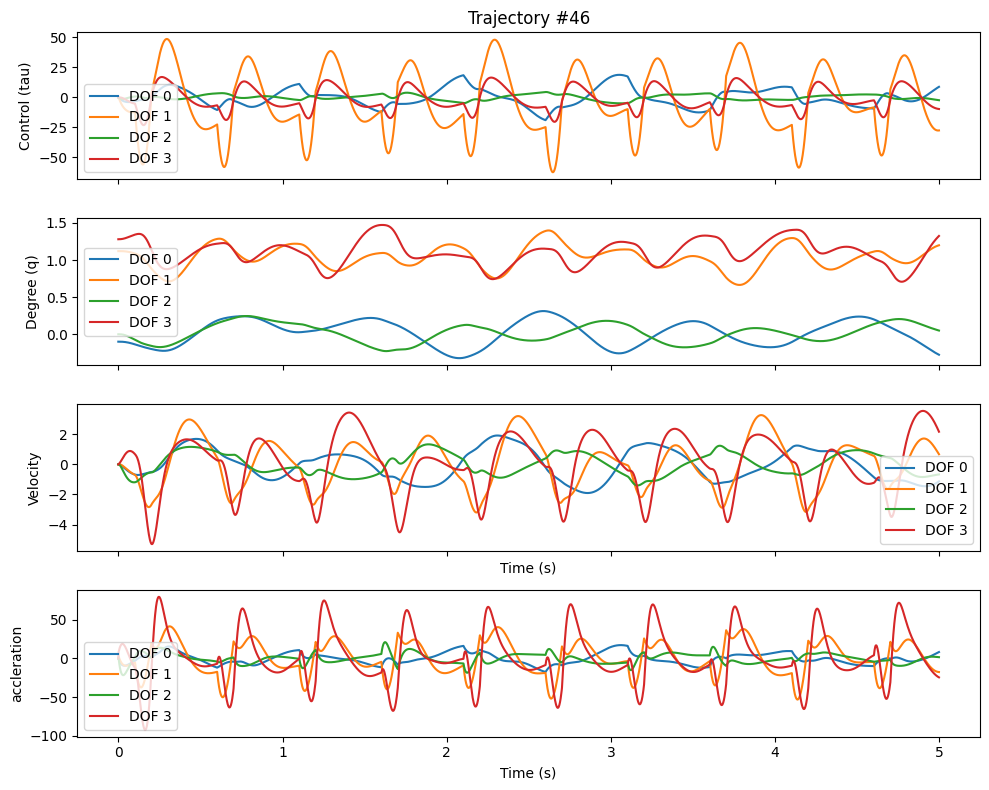

In [82]:
i = 45 # index from 0 to N-1
u = us[i]
q = qs[i]
q_t= qs_t[i]
q_tt = qs_tt[i]

fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

axes[0].set_title(f"Trajectory #{i+1}")
axes[0].plot(ts, u)
axes[0].set_ylabel("Control (tau)")
axes[0].legend([f"DOF {j}" for j in range(u.shape[1])])

axes[1].plot(ts, q)
axes[1].set_ylabel("Degree (q)")
axes[1].legend([f"DOF {j}" for j in range(q.shape[1])])

axes[2].plot(ts, q_t)
axes[2].set_ylabel("Velocity")
axes[2].set_xlabel("Time (s)")
axes[2].legend([f"DOF {j}" for j in range(q_t.shape[1])])

axes[3].plot(ts, q_tt)
axes[3].set_ylabel("accleration")
axes[3].set_xlabel("Time (s)")
axes[3].legend([f"DOF {j}" for j in range(q_tt.shape[1])])


plt.tight_layout()
plt.show()

# checking the derivation of trajectories with each other

C:\Users\sormeabkenar\AppData\Local\Temp\ipykernel_11416\1194056282.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


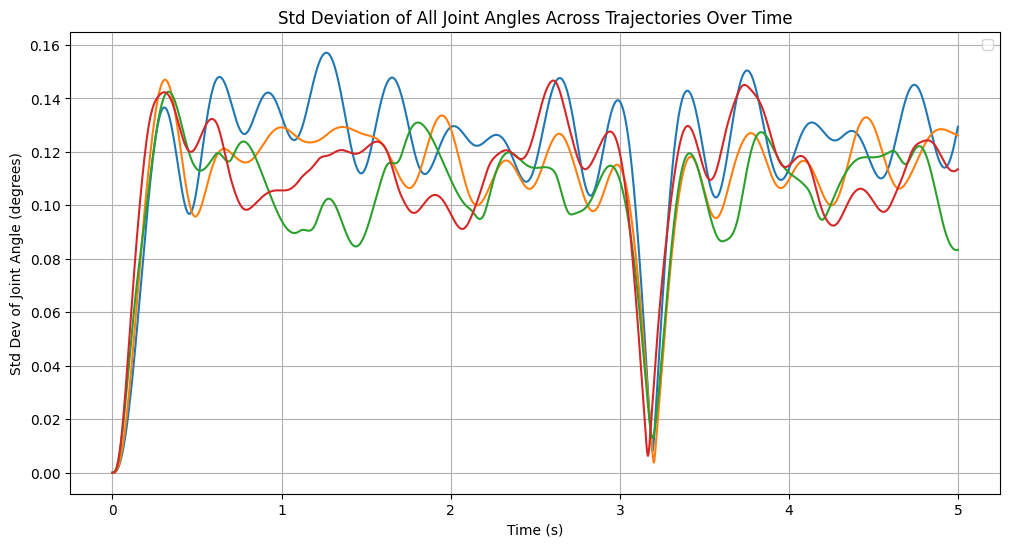

In [83]:
max_time = ts[-1]
time_points = jnp.arange(0, max_time + 1, 1)  # whole seconds

indices = [jnp.argmin(jnp.abs(ts - t)) for t in time_points]

plt.figure(figsize=(12, 6))

for joint_idx in range(qs.shape[2]):  # for all 4 joints
    plt.plot(ts, jnp.std(qs[...,joint_idx], axis=0))

plt.xlabel('Time (s)')
plt.ylabel('Std Dev of Joint Angle (degrees)')
plt.title('Std Deviation of All Joint Angles Across Trajectories Over Time')
plt.legend()
plt.grid()
plt.show()


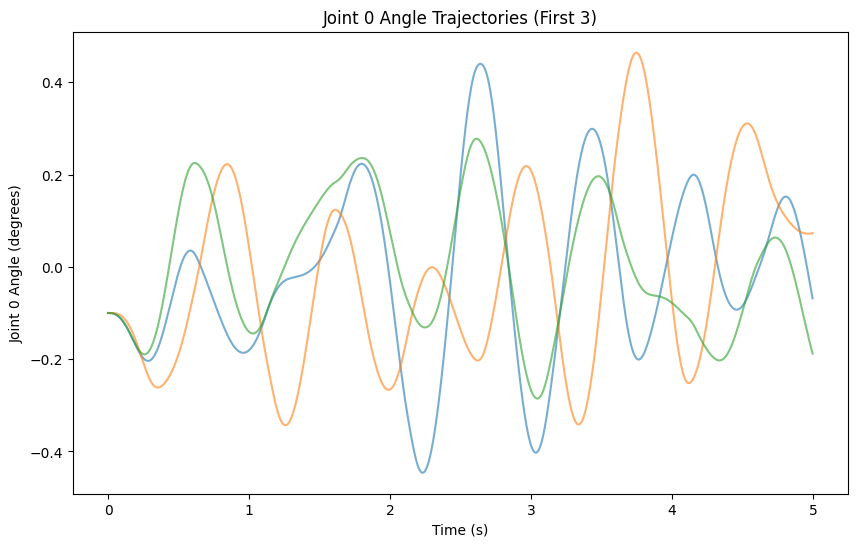

In [84]:
joint_idx = 0
plt.figure(figsize=(10,6))
for i in range(min(3, N)):  # Plot only first 3 trajectories
    plt.plot(ts, qs[i, :, joint_idx], alpha=0.6)
plt.xlabel('Time (s)')
plt.ylabel(f'Joint {joint_idx} Angle (degrees)')
plt.title(f'Joint {joint_idx} Angle Trajectories (First 3)')
plt.show()


# Standardization

### Method 1: Standardization for each degree of freedom 

In [85]:
# Compute Standardization statistics on the *entire* dataset BEFORE splitting
qs_mean, qs_std = jnp.mean(qs, axis=(0,1)), jnp.std(qs, axis=(0,1))
qs_t_mean, qs_t_std = jnp.mean(qs_t, axis=(0,1)), jnp.std(qs_t, axis=(0,1))
qs_tt_mean, qs_tt_std = jnp.mean(qs_tt, axis=(0,1)), jnp.std(qs_tt, axis=(0,1))
us_mean, us_std = jnp.mean(us, axis=(0,1)), jnp.std(us, axis=(0,1))

print ("Standardization data:")
print ("degree_mean:",qs_mean, "degree_std:",qs_std)
print ("velocity_mean:",qs_t_mean, "velocity_std:",qs_t_std)
print ("acceleration_mean:",qs_tt_mean, "acceleration_std:",qs_tt_std)
print ("torque_mean:",us_mean, "torque_std:",us_std)

Standardization data:
degree_mean: [7.7221874e-04 1.0332161e+00 1.1567774e-03 1.1066628e+00] degree_std: [0.154935   0.15713288 0.10738045 0.1683601 ]
velocity_mean: [ 0.00665494  0.00546817  0.00053695 -0.01186672] velocity_std: [1.0029976 1.5492026 0.613365  1.8483601]
acceleration_mean: [-0.17164373  0.23890488  0.03558724  0.157787  ] acceleration_std: [ 7.856468  20.680706   5.8901777 32.150173 ]
torque_mean: [-0.17494874 -4.3679194   0.04430274 -1.5036372 ] torque_std: [ 7.8457475 26.273884   2.3094869  9.124658 ]


In [86]:
q_std = (qs - qs_mean) / qs_std           
q_t_std = qs_t / qs_t_std
q_tt_std = qs_tt * qs_std / (qs_t_std **2)
u_std =((us - us_mean) / us_std ) 

print("qs_std shape:", q_std.shape)
print("us_std shape:", u_std.shape)



qs_std shape: (50, 2500, 4)
us_std shape: (50, 2500, 4)


In [88]:
t_scale = ((qs_t_std[0]/ qs_std[0]) + (qs_t_std[1]/ qs_std[1] ) + (qs_t_std[2]/ qs_std[2]) +(qs_t_std[3]/ qs_std[3]))/4 * ts

In [89]:
print ("after rescaling the data:")
print ("degree_mean:",jnp.mean(q_std, axis=(0,1)), "degree_std:",jnp.std(q_std, axis=(0,1)))
print ("velocity_mean:",jnp.mean(q_t_std, axis=(0,1)), "velocity_std:",jnp.std(q_t_std, axis=(0,1)))
print ("acceleration_mean:",jnp.mean(q_tt_std, axis=(0,1)), "acceleration_std:",jnp.std(q_tt_std, axis=(0,1)))

print ("intial timescale", ts[1] - ts[0] )
print ("new timescale:" , t_scale[1] - t_scale[0])


after rescaling the data:
degree_mean: [-7.8125000e-09  7.8588869e-07 -2.9296876e-09  1.8334961e-07] degree_std: [1.         0.99999994 1.         1.0000001 ]
velocity_mean: [ 0.00663508  0.00352964  0.00087542 -0.00642014] velocity_std: [1.         1.         0.99999994 1.        ]
acceleration_mean: [-0.02643489  0.01564138  0.01015738  0.00777578] acceleration_std: [1.2099769 1.3539917 1.6811854 1.5843434]
intial timescale 0.002
new timescale: 0.016511772


In [90]:
# dq/dt ≈ (q[i+1] - q[i]) / (t_scale[i+1] - t_scale[i])
q_t_check = (q_std[:, 1:, :] - q_std[:, :-1, :]) / (t_scale[1:] - t_scale[:-1])[None, :, None]



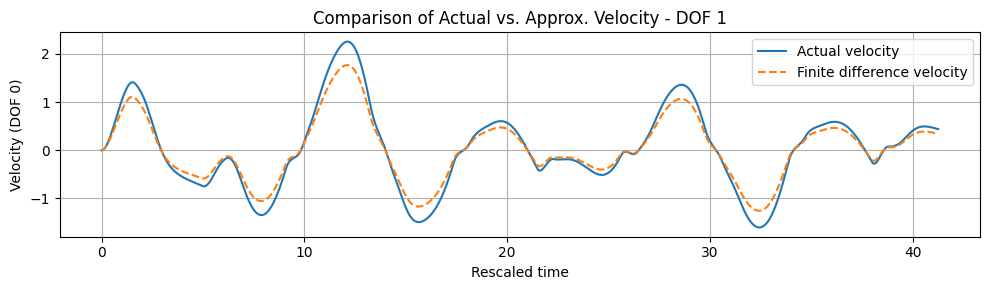

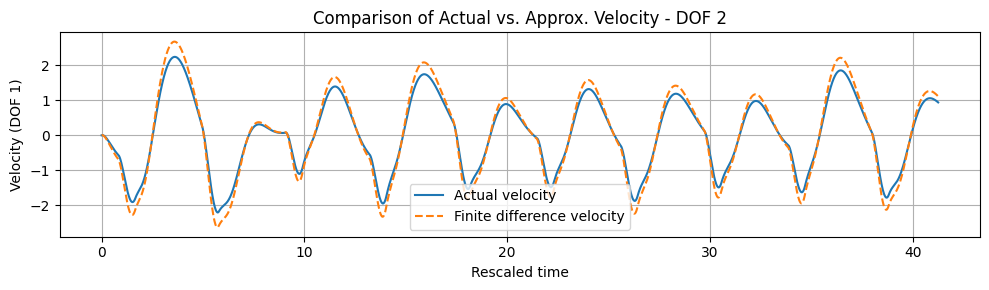

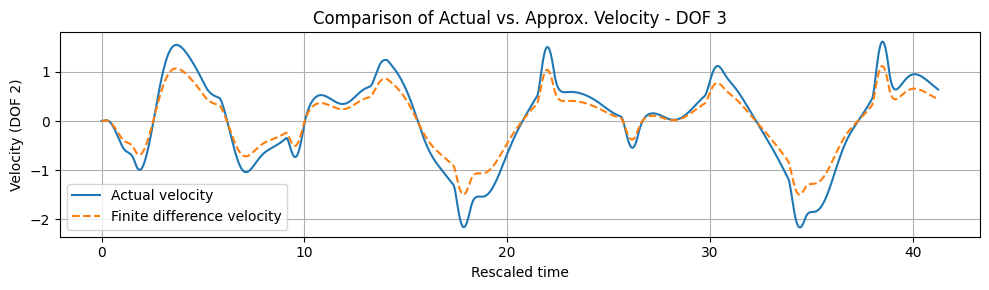

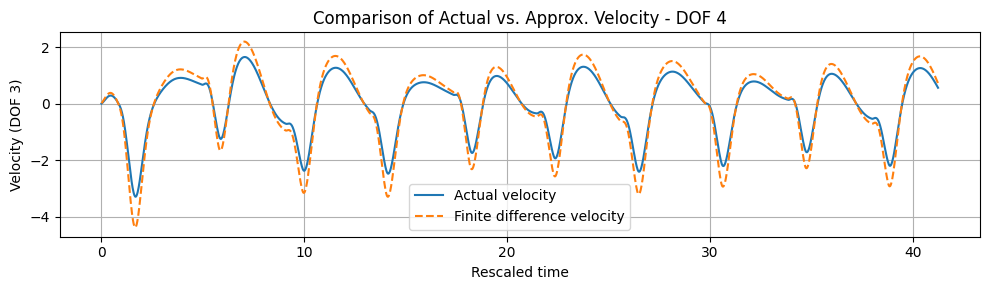

In [91]:
i = 9 # index from 0 to N-1

# Actual velocity from data
q_t_actual = q_t_std[i, :-1, :]  # shape: (T-1, DOF)

DOF = q_std.shape[-1]
for dof in range(DOF):
    plt.figure(figsize=(10, 3))
    plt.plot(t_scale[:-1], q_t_actual[:, dof], label="Actual velocity")
    plt.plot(t_scale[:-1], q_t_check[i,:, dof], '--', label="Finite difference velocity")
    plt.xlabel("Rescaled time")
    plt.ylabel(f"Velocity (DOF {dof})")
    plt.title(f"Comparison of Actual vs. Approx. Velocity - DOF {dof+1}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [92]:
# dv/dt ≈ (q_t[i+1] - q_t[i]) / (t_scale[i+1] - t_scale[i])
q_tt_check = (q_t_std[:, 1:, :] - q_t_std[:, :-1, :]) / (t_scale[1:] - t_scale[:-1])[None, :, None]

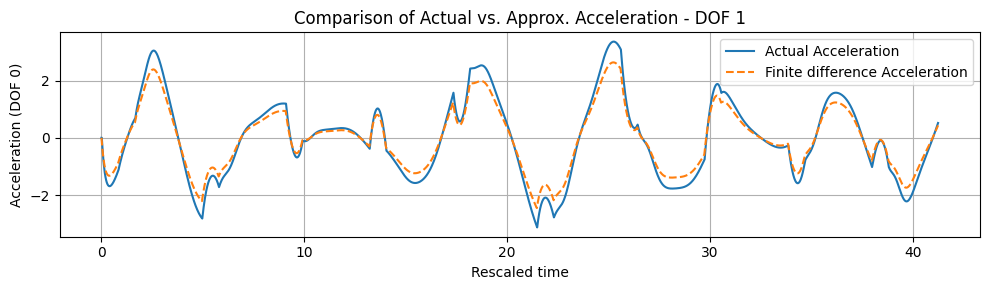

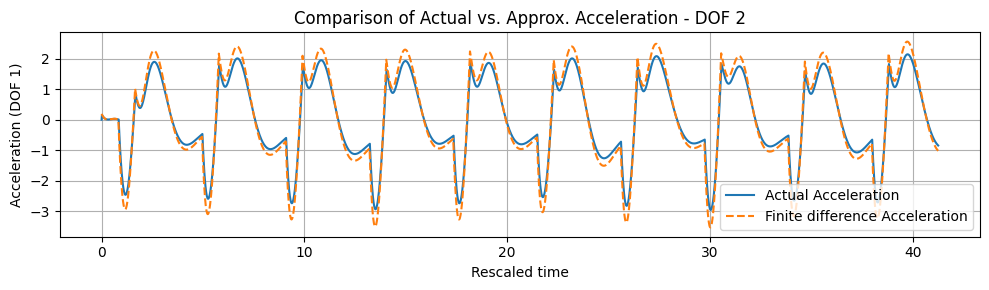

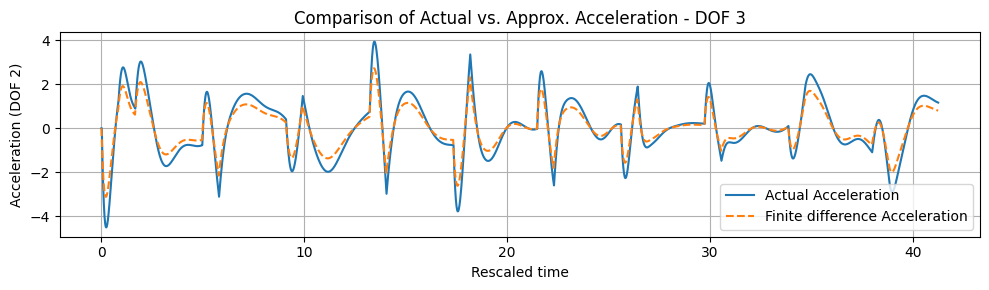

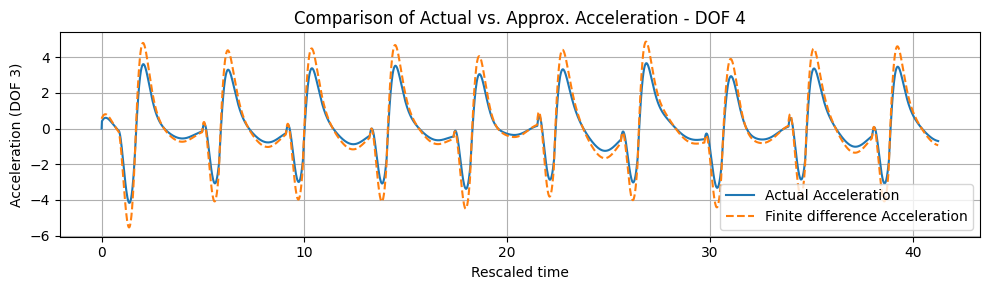

In [93]:
i = 21 # index from 0 to N-1

# Actual acceleration from data
q_tt_actual = q_tt_std[i, :-1, :]  # shape: (T-1, DOF)

DOF = q_std.shape[-1]
for dof in range(DOF):
    plt.figure(figsize=(10, 3))
    plt.plot(t_scale[:-1], q_tt_actual[:, dof], label="Actual Acceleration")
    plt.plot(t_scale[:-1], q_tt_check[i,:, dof], '--', label="Finite difference Acceleration")
    plt.xlabel("Rescaled time")
    plt.ylabel(f"Acceleration (DOF {dof})")
    plt.title(f"Comparison of Actual vs. Approx. Acceleration - DOF {dof+1}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Standardization

### Method 2: Standardization for all 4 degree of freedom together

In [94]:
# Load the data
data = jnp.load('juggle_data.npz')
ts = data['ts']       # shape: (T,)
us = data['us']       # shape: (N, T, DOF)
qs = data['qs']       # shape: (N, T, DOF)
qs_t = data['qs_t']   # shape: (N, T, DOF)
qs_tt = data['qs_tt'] # shape: (N, T, DOF)

print("ts shape:", ts.shape)
print("us shape:", us.shape)
print("qs shape:", qs.shape)

T_total = ts.shape[0]
T_cut = int(0.5 * T_total)

# 2. Truncate the time series
ts = ts[:T_cut]
us = us[:, :T_cut, :]
qs = qs[:, :T_cut, :]
qs_t = qs_t[:, :T_cut, :]
qs_tt = qs_tt[:, :T_cut, :]

print("ts shape:", ts.shape)
print("us shape:", us.shape)
print("qs shape:", qs.shape)

ts shape: (5001,)
us shape: (50, 5001, 4)
qs shape: (50, 5001, 4)
ts shape: (2500,)
us shape: (50, 2500, 4)
qs shape: (50, 2500, 4)


In [95]:
# Compute Standardization statistics on the *entire* dataset BEFORE splitting
qs_mean, qs_std = jnp.mean(qs), jnp.std(qs)
qs_t_mean, qs_t_std = jnp.mean(qs_t), jnp.std(qs_t)
qs_tt_mean, qs_tt_std = jnp.mean(qs_tt), jnp.std(qs_tt)
us_mean, us_std = jnp.mean(us, axis=(0,1)), jnp.std(us, axis=(0,1))

print ("Standardization data:")
print ("degree_mean:",qs_mean, "degree_std:",qs_std)
print ("velocity_mean:",qs_t_mean, "velocity_std:",qs_t_std)
print ("acceleration_mean:",qs_tt_mean, "acceleration_std:",qs_tt_std)
print ("torque_mean:",us_mean, "torque_std:",us_std)

Standardization data:
degree_mean: 0.53545207 degree_std: 0.55542237
velocity_mean: 0.00019829102 velocity_std: 1.3415383
acceleration_mean: 0.06515807 acceleration_std: 19.734734
torque_mean: [-0.17494874 -4.3679194   0.04430274 -1.5036372 ] torque_std: [ 7.8457475 26.273884   2.3094869  9.124658 ]


In [107]:
q_std = (qs - qs_mean) / qs_std           
q_t_std = qs_t / qs_t_std
q_tt_std = qs_tt * qs_std / (qs_t_std **2)
u_std =((us - us_mean) / us_std ) 

print("q_std shape:", q_std.shape)
print("u_std shape:", u_std.shape)

q_std shape: (50, 2500, 4)
u_std shape: (50, 2500, 4)


In [101]:
t_scale = (qs_t_std/ qs_std)*ts

print (t_scale.shape)

(2500,)


In [102]:
print ("after rescaling the data:")
print ("degree_mean:",jnp.mean(q_std, axis=(0,1)), "degree_std:",jnp.std(q_std, axis=(0,1)))
print ("velocity_mean:",jnp.mean(q_t_std, axis=(0,1)), "velocity_std:",jnp.std(q_t_std, axis=(0,1)))
print ("acceleration_mean:",jnp.mean(q_tt_std, axis=(0,1)), "acceleration_std:",jnp.std(q_tt_std, axis=(0,1)))

print ("intial timescale", ts[1] - ts[0] )
print ("new timescale:" , t_scale[1] - t_scale[0])

after rescaling the data:
degree_mean: [-0.9626545   0.89619035 -0.9619621   1.028426  ] degree_std: [0.27894986 0.28290698 0.19333115 0.30312088]
velocity_mean: [ 0.0049607   0.004076    0.00040025 -0.00884566] velocity_std: [0.74764746 1.1547956  0.45721015 1.3777916 ]
acceleration_mean: [-0.05297183  0.07372978  0.01098273  0.04869543] acceleration_std: [2.4246252 6.382378  1.8177978 9.9220295]
intial timescale 0.002
new timescale: 0.004830696


In [103]:
# dq/dt ≈ (q[i+1] - q[i]) / (t_scale[i+1] - t_scale[i])
q_t_check = (q_std[:, 1:, :] - q_std[:, :-1, :]) / (t_scale[1:] - t_scale[:-1])[None, :, None]

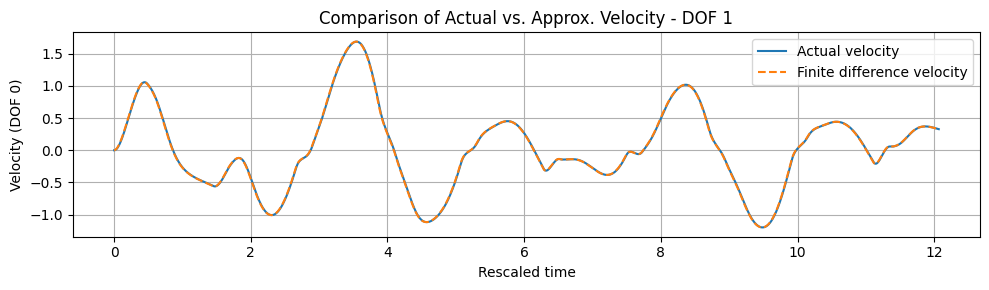

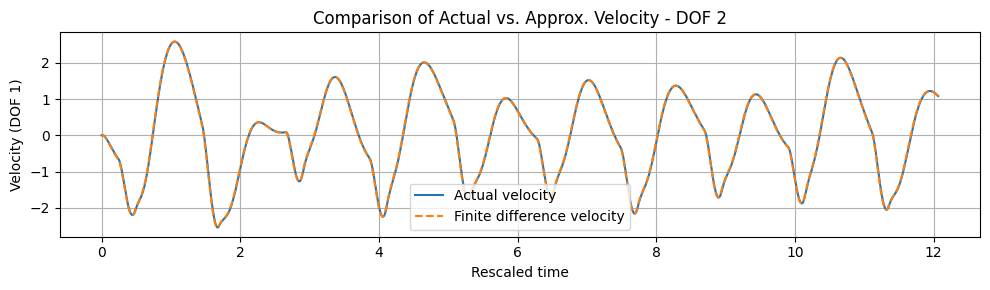

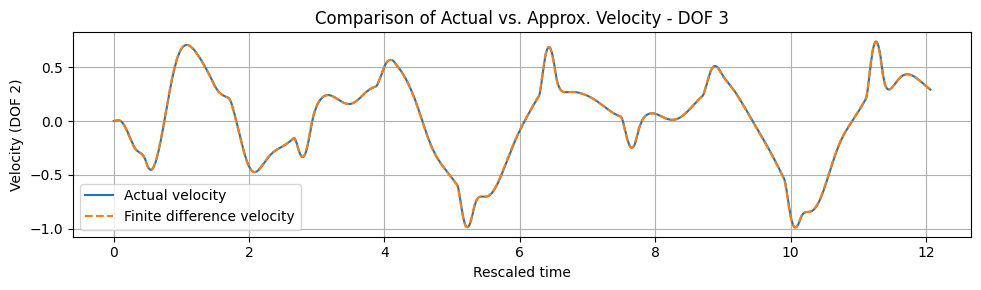

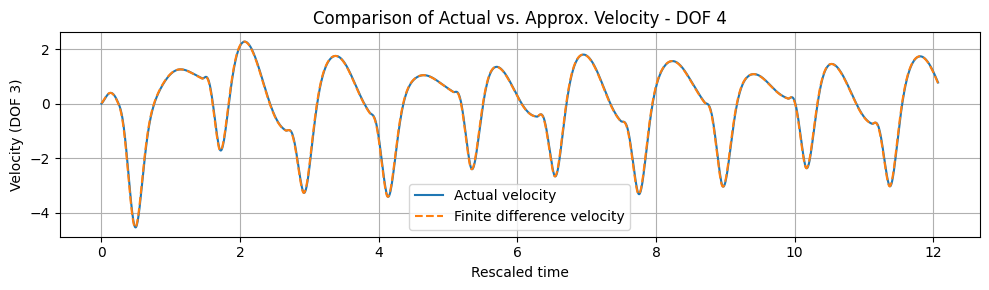

In [104]:
i = 9 # index from 0 to N-1

# Actual velocity from data
q_t_actual = q_t_std[i, :-1, :]  # shape: (T-1, DOF)

DOF = q_std.shape[-1]
for dof in range(DOF):
    plt.figure(figsize=(10, 3))
    plt.plot(t_scale[:-1], q_t_actual[:, dof], label="Actual velocity")
    plt.plot(t_scale[:-1], q_t_check[i,:, dof], '--', label="Finite difference velocity")
    plt.xlabel("Rescaled time")
    plt.ylabel(f"Velocity (DOF {dof})")
    plt.title(f"Comparison of Actual vs. Approx. Velocity - DOF {dof+1}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [105]:
# dv/dt ≈ (q_t[i+1] - q_t[i]) / (t_scale[i+1] - t_scale[i])
q_tt_check = (q_t_std[:, 1:, :] - q_t_std[:, :-1, :]) / (t_scale[1:] - t_scale[:-1])[None, :, None]

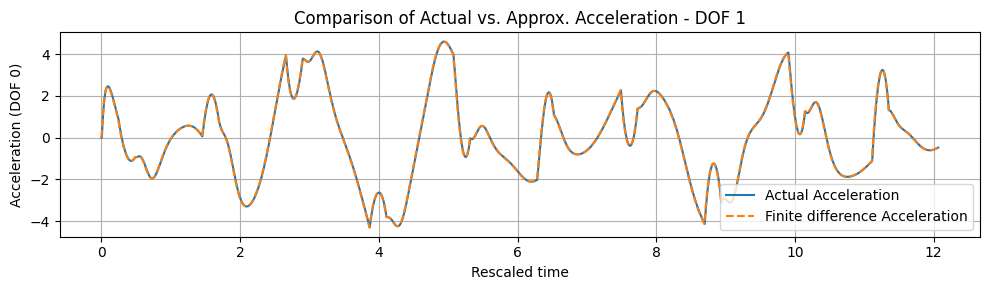

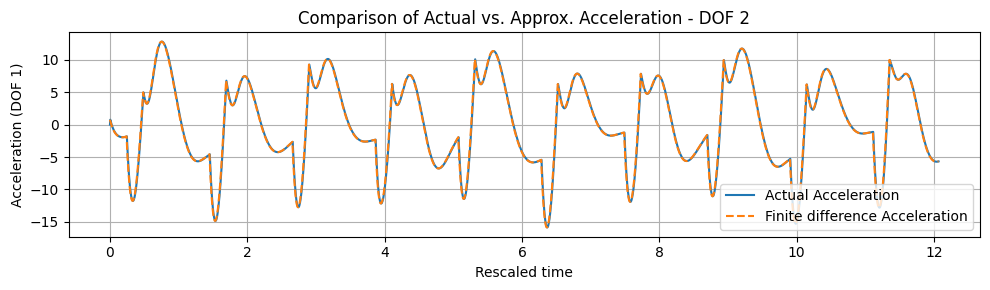

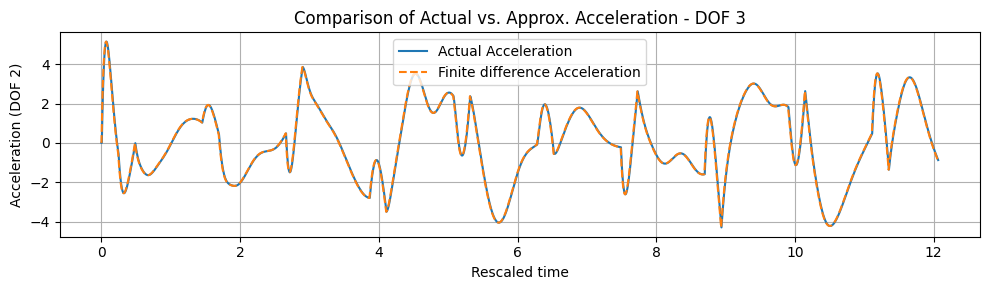

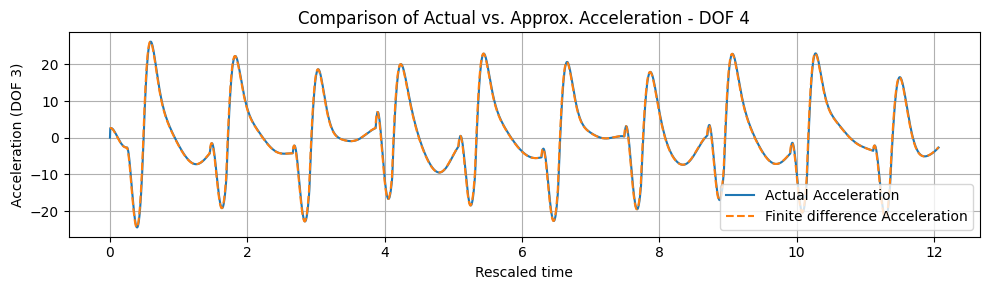

In [108]:
i = 16 # index from 0 to N-1

# Actual acceleration from data
q_tt_actual = q_tt_std[i, :-1, :]  # shape: (T-1, DOF)

DOF = q_std.shape[-1]
for dof in range(DOF):
    plt.figure(figsize=(10, 3))
    plt.plot(t_scale[:-1], q_tt_actual[:, dof], label="Actual Acceleration")
    plt.plot(t_scale[:-1], q_tt_check[i,:, dof], '--', label="Finite difference Acceleration")
    plt.xlabel("Rescaled time")
    plt.ylabel(f"Acceleration (DOF {dof})")
    plt.title(f"Comparison of Actual vs. Approx. Acceleration - DOF {dof+1}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()